In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Update the path to the location of the respective CSV file
#NOTE: This code was developed on google colab so this step might have to be fixed
file_path = '/content/drive/MyDrive/Colab Notebooks/preprocessed_data.csv'

#Dataframe conversion
data = pd.read_csv(file_path, encoding='latin1')

# Define the target and features
X = data.drop(columns=['risk'])
y = data['risk']

# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train_encoded, X_test_encoded, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

smote = SMOTE()
X_train_encoded, y_train = smote.fit_resample(X_train_encoded, y_train)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import regularizers

# Convert y_train to NumPy array to avoid indexing issues
y_train_np = np.array(y_train)

# Define K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = []

# Build the DNN model
def build_dnn_model(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))  # Specify the input shape
    model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.1)))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.1)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))  # For binary classification, use 'sigmoid'


    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("\nPerforming K-Fold Cross-Validation...\n")

# Iterate over each fold
for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_encoded, y_train_np)):
    print(f"Training Fold {fold_idx + 1} / {kfold.get_n_splits()}")

    # Split the data
    X_train_fold, X_val_fold = X_train_encoded[train_idx], X_train_encoded[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

    # Build and train the model
    model = build_dnn_model(X_train_fold.shape[1])
    model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=0)

    # Predict on validation fold
    y_val_pred = (model.predict(X_val_fold) > 0.5).astype(int)

    # Compute F1 score for the fold
    f1_fold = f1_score(y_val_fold, y_val_pred, average='weighted')
    cv_f1_scores.append(f1_fold)

    print(f"Fold {fold_idx + 1} F1 Score: {f1_fold:.4f}\n")

# Print mean and std of cross-validation scores
print(f"Mean F1 Score from Cross-Validation: {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")

# Train the final model on the entire dataset
print("\nTraining final model on full dataset...")
final_model = build_dnn_model(X_train_encoded.shape[1])
final_model.fit(X_train_encoded, y_train_np, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test set
y_pred = (final_model.predict(X_test_encoded) > 0.5).astype(int)

# Determine if the problem is binary or multi-class
average_type = 'binary' if len(set(y_train)) == 2 else 'weighted'

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=average_type)
recall = recall_score(y_test, y_pred, average=average_type)
f1 = f1_score(y_test, y_pred, average=average_type)
kappa = cohen_kappa_score(y_test, y_pred)

# Print individual metrics
print("\nFinal Model Test Set Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")



Performing K-Fold Cross-Validation...

Training Fold 1 / 5
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Fold 1 F1 Score: 0.9650

Training Fold 2 / 5
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Fold 2 F1 Score: 0.9695

Training Fold 3 / 5
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Fold 3 F1 Score: 0.9683

Training Fold 4 / 5
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Fold 4 F1 Score: 0.9572

Training Fold 5 / 5
2070/2070 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Fold 5 F1 Score: 0.9705

Mean F1 Score from Cross-Validation: 0.9661 ± 0.0048

Training final model on full dataset...
Epoch 1/10
10349/10349 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.7338 - loss: 0.9101
Epoch 2/10
10349/10349 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8407 - loss: 0.4755
Epoch 3/10
10349/10349 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8857 - loss: 0.4056
Epoch 4/10
10349/10349 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.9182 - loss: 0.3530
Epoch 5/10
10349/10349 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - acc

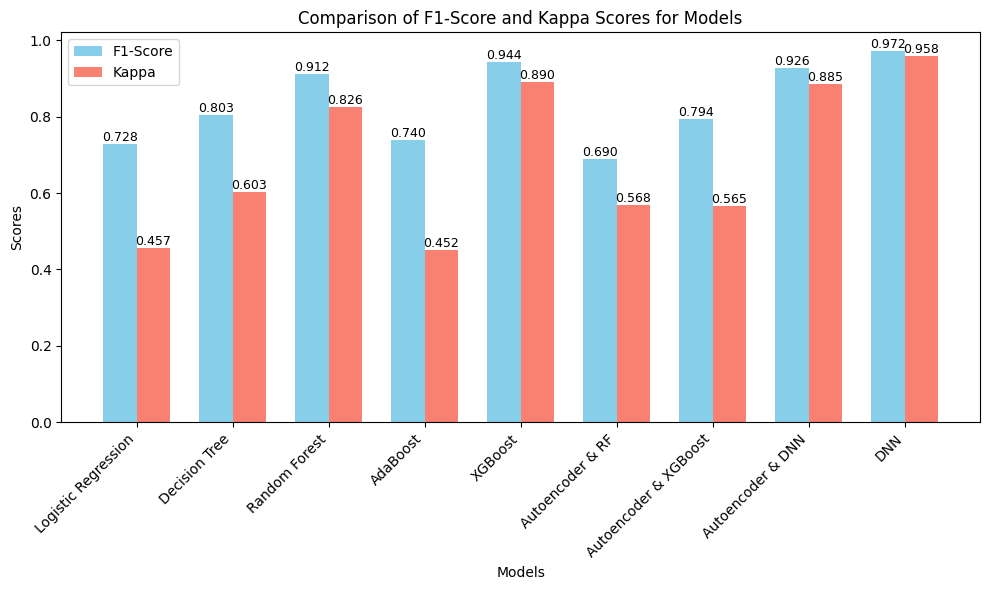

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost',
          'Autoencoder & RF', 'Autoencoder & XGBoost', 'Autoencoder & DNN', 'DNN']
f1_scores = [0.728, 0.803, 0.912, 0.740, 0.944, 0.690, 0.794, 0.926, 0.972]
kappa_scores = [0.457, 0.603, 0.826, 0.452, 0.890, 0.568, 0.565, 0.885, 0.958]

# Plotting
x = np.arange(len(models))  # x-axis for models
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))

# Bar positions
rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='skyblue')
rects2 = ax.bar(x + width/2, kappa_scores, width, label='Kappa', color='salmon')

# Labeling
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Comparison of F1-Score and Kappa Scores for Models')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()

# Add labels on top of the bars
for rect in rects1:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

# Display the plot
plt.tight_layout()
plt.show()

